In [17]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import joblib

In [18]:
np.random.seed(42)

n_samples = 500 

X1 = np.random.uniform(1,10,n_samples) 
noise = np.random.normal(0,5,n_samples)
y = 10*X1 + noise

In [19]:
data = pd.DataFrame({'Hours_Studied':X1,'Test_Score':y})
data.head()

,Hours_Studied,Test_Score
0,4.370861,45.417391
1,9.556429,104.945142
2,7.587945,80.631574
3,6.387926,60.994745
4,2.404168,19.549604


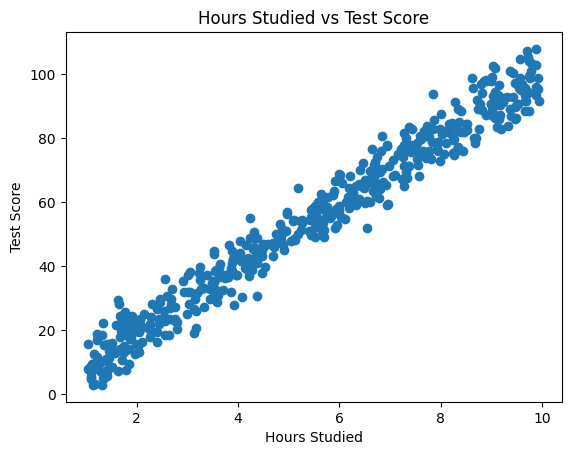

               Hours_Studied  Test_Score
Hours_Studied       1.000000    0.983399
Test_Score          0.983399    1.000000


In [24]:
plt.scatter(data['Hours_Studied'],data['Test_Score'])
plt.title('Hours Studied vs Test Score') 
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.show()


corr_matrix = data.corr()
print(corr_matrix) 

In [25]:
X = data[['Hours_Studied']]
y = data['Test_Score']

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2, random_state = 42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [30]:
model = LinearRegression()

model.fit(X_train_scaled,y_train)

print("Coefficient",model.coef_) 
print("Intercept",model.intercept_)

Coefficient [27.31629308]
Intercept 55.31588683514129


In [31]:
new_data = np.array([[6]])
new_data_df = pd.DataFrame(new_data,columns =['Hours_Studied']) 

new_data_scaled = scaler.transform(new_data_df)

single_prediction = model.predict(new_data_scaled)

print(f"Predicted Test score for 6 hours of study: {single_prediction[0]}")

Predicted Test score for 6 hours of study: 60.03282292232381


In [32]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test,y_pred) 
r2 = r2_score(y_test,y_pred)

print(f"Mean Squared error: {mse}")
print(f"R-squared:{r2}")

Mean Squared error: 26.105427937987933
R-squared:0.9645671742510007


In [35]:
joblib.dump(model,'linear_regression_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [36]:
loaded_model = joblib.load('linear_regression_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')


new_data = np.array([[6]])
new_data_df = pd.DataFrame(new_data,columns =['Hours_Studied']) 

new_data_scaled = loaded_scaler.transform(new_data_df)

single_prediction = loaded_model.predict(new_data_scaled)

print(f"Predicted Test score for 6 hours of study: {single_prediction[0]}")

Predicted Test score for 6 hours of study: 60.03282292232381
